In [1]:
a=22
a

22

In [3]:
type(a)

int

In [5]:
b=4.5
b

4.5

In [7]:
type(b)

float

In [25]:
import cv2

def detect_faces_and_eyes():
    # Load the pre-trained classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    # Check if classifiers loaded properly
    if face_cascade.empty():
        print("Error loading face cascade")
        return
    if eye_cascade.empty():
        print("Error loading eye cascade")
        return
    
    # Initialize video capture (0 is default webcam)
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error opening video stream")
        return
    
    while True:
        # Capture frame-by-frame
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert to grayscale for detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
        # Draw rectangles around faces and detect eyes in each face
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            
            # Region of Interest (ROI) for eyes detection (upper half of face)
            roi_gray = gray[y:y+int(h/2), x:x+w]
            roi_color = frame[y:y+int(h/2), x:x+w]
            
            # Detect eyes in the face ROI
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(20, 20)
            )
            
            # Draw rectangles around eyes
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
        
        # Display the resulting frame
        cv2.imshow('Face and Eye Detection', frame)
        
        # Break the loop on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release the capture and destroy windows
    cap.release()
    cv2.destroyAllWindows()

def detect_in_image(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image")
        return
    
    # Load the classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Process each face
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        # ROI for eyes
        roi_gray = gray[y:y+int(h/2), x:x+w]
        roi_color = image[y:y+int(h/2), x:x+w]
        
        # Detect eyes
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(20, 20)
        )
        
        # Draw eye rectangles
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
    
    # Display the result
    cv2.imshow('Image Detection', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Face and Eye Detection Project")
    print("1. Real-time detection from webcam")
    print("2. Detect in an image file")
    
    choice = input("Enter your choice (1 or 2): ")
    
    if choice == '1':
        detect_faces_and_eyes()
    elif choice == '2':
        image_path = input("Enter image file path: ")
        detect_in_image(image_path)
    else:
        print("Invalid choice")

Face and Eye Detection Project
1. Real-time detection from webcam
2. Detect in an image file


Enter your choice (1 or 2):  1


In [29]:
import cv2

def detect_faces_eyes_smiles():
    # Load the pre-trained classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
    
    # Check if classifiers loaded properly
    if face_cascade.empty():
        print("Error loading face cascade")
        return
    if eye_cascade.empty():
        print("Error loading eye cascade")
        return
    if smile_cascade.empty():
        print("Error loading smile cascade")
        return
    
    # Initialize video capture (0 is default webcam)
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error opening video stream")
        return
    
    while True:
        # Capture frame-by-frame
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert to grayscale for detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
        # Draw rectangles around faces and detect eyes/smiles in each face
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            
            # Region of Interest (ROI) for eyes detection (upper half of face)
            roi_gray_eyes = gray[y:y+int(h/2), x:x+w]
            roi_color_eyes = frame[y:y+int(h/2), x:x+w]
            
            # Detect eyes in the face ROI
            eyes = eye_cascade.detectMultiScale(
                roi_gray_eyes,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(20, 20)
            )
            
            # Draw rectangles around eyes
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color_eyes, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
            
            # Region of Interest (ROI) for smile detection (lower half of face)
            roi_gray_smile = gray[y+int(h/2):y+h, x:x+w]
            roi_color_smile = frame[y+int(h/2):y+h, x:x+w]
            
            # Detect smiles in the face ROI
            smiles = smile_cascade.detectMultiScale(
                roi_gray_smile,
                scaleFactor=1.7,
                minNeighbors=20,
                minSize=(25, 25)
            )
            
            # Draw rectangles around smiles
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color_smile, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)
                cv2.putText(frame, 'Smile Detected', (x, y+h+30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        # Display the resulting frame
        cv2.imshow('Face, Eye and Smile Detection', frame)
        
        # Break the loop on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release the capture and destroy windows
    cap.release()
    cv2.destroyAllWindows()

def detect_in_image(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image")
        return
    
    # Load the classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Process each face
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        # ROI for eyes (upper half of face)
        roi_gray_eyes = gray[y:y+int(h/2), x:x+w]
        roi_color_eyes = image[y:y+int(h/2), x:x+w]
        
        # Detect eyes
        eyes = eye_cascade.detectMultiScale(
            roi_gray_eyes,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(20, 20)
        )
        
        # Draw eye rectangles
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color_eyes, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
        
        # ROI for smile (lower half of face)
        roi_gray_smile = gray[y+int(h/2):y+h, x:x+w]
        roi_color_smile = image[y+int(h/2):y+h, x:x+w]
        
        # Detect smiles
        smiles = smile_cascade.detectMultiScale(
            roi_gray_smile,
            scaleFactor=1.7,
            minNeighbors=20,
            minSize=(25, 25)
        )
        
        # Draw smile rectangles
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color_smile, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)
            cv2.putText(image, 'Smile Detected', (x, y+h+30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
    # Display the result
    cv2.imshow('Face, Eye and Smile Detection', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Face, Eye and Smile Detection Project")
    print("1. Real-time detection from webcam")
    print("2. Detect in an image file")
    
    choice = input("Enter your choice (1 or 2): ")
    
    if choice == '1':
        detect_faces_eyes_smiles()
    elif choice == '2':
        image_path = input("Enter image file path: ")
        detect_in_image(image_path)
    else:
        print("Invalid choice")

Face, Eye and Smile Detection Project
1. Real-time detection from webcam
2. Detect in an image file


Enter your choice (1 or 2):  1


In [19]:
import cv2
import numpy as np
import argparse

def initialize_models():
    # Load face detection model
    face_proto = "opencv_face_detector.pbtxt"
    face_model = "opencv_face_detector_uint8.pb"
    face_net = cv2.dnn.readNet(face_model, face_proto)
    
    # Load age detection model
    age_proto = "age_deploy.prototxt"
    age_model = "age_net.caffemodel"
    age_net = cv2.dnn.readNet(age_model, age_proto)
    
    # Load gender detection model
    gender_proto = "gender_deploy.prototxt"
    gender_model = "gender_net.caffemodel"
    gender_net = cv2.dnn.readNet(gender_model, gender_proto)
    
    # Age and gender lists
    age_list = ['(0-2)', '(4-6)', '(8-12)', '(15-20)', '(25-32)', '(38-43)', '(48-53)', '(60-100)']
    gender_list = ['Male', 'Female']
    
    return face_net, age_net, gender_net, age_list, gender_list

def detect_faces(net, frame, conf_threshold=0.7):
    frame_opencv_dnn = frame.copy()
    frame_height = frame_opencv_dnn.shape[0]
    frame_width = frame_opencv_dnn.shape[1]
    blob = cv2.dnn.blobFromImage(frame_opencv_dnn, 1.0, (300, 300), [104, 117, 123], True, False)
    
    net.setInput(blob)
    detections = net.forward()
    faces = []
    
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * frame_width)
            y1 = int(detections[0, 0, i, 4] * frame_height)
            x2 = int(detections[0, 0, i, 5] * frame_width)
            y2 = int(detections[0, 0, i, 6] * frame_height)
            faces.append([x1, y1, x2, y2])
            
    return faces

def predict_age_gender(frame, face, age_net, gender_net, age_list, gender_list):
    # Get face ROI
    x1, y1, x2, y2 = face
    face_roi = frame[y1:y2, x1:x2]
    
    if face_roi.size == 0:
        return None, None
    
    # Preprocess for gender prediction
    gender_blob = cv2.dnn.blobFromImage(face_roi, 1.0, (227, 227), (78.4263377603, 87.7689143744, 114.895847746), swapRB=False)
    gender_net.setInput(gender_blob)
    gender_preds = gender_net.forward()
    gender = gender_list[gender_preds[0].argmax()]
    
    # Preprocess for age prediction
    age_blob = cv2.dnn.blobFromImage(face_roi, 1.0, (227, 227), (78.4263377603, 87.7689143744, 114.895847746), swapRB=False)
    age_net.setInput(age_blob)
    age_preds = age_net.forward()
    age = age_list[age_preds[0].argmax()]
    
    return gender, age

def real_time_detection():
    # Initialize models
    face_net, age_net, gender_net, age_list, gender_list = initialize_models()
    
    # Open webcam
    cap = cv2.VideoCapture(0)
    padding = 20
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Detect faces
        faces = detect_faces(face_net, frame)
        
        for face in faces:
            x1, y1, x2, y2 = face
            
            # Add padding to face ROI
            x1 = max(0, x1 - padding)
            y1 = max(0, y1 - padding)
            x2 = min(frame.shape[1], x2 + padding)
            y2 = min(frame.shape[0], y2 + padding)
            
            # Draw rectangle around face
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Predict age and gender
            gender, age = predict_age_gender(frame, (x1, y1, x2, y2), age_net, gender_net, age_list, gender_list)
            
            if gender and age:
                # Display predictions
                label = f"{gender}, {age}"
                cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
        
        # Display output
        cv2.imshow("Age and Gender Detection", frame)
        
        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

def image_detection(image_path):
    # Initialize models
    face_net, age_net, gender_net, age_list, gender_list = initialize_models()
    
    # Read image
    frame = cv2.imread(image_path)
    if frame is None:
        print("Error loading image")
        return
    
    padding = 20
    
    # Detect faces
    faces = detect_faces(face_net, frame)
    
    for face in faces:
        x1, y1, x2, y2 = face
        
        # Add padding to face ROI
        x1 = max(0, x1 - padding)
        y1 = max(0, y1 - padding)
        x2 = min(frame.shape[1], x2 + padding)
        y2 = min(frame.shape[0], y2 + padding)
        
        # Draw rectangle around face
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Predict age and gender
        gender, age = predict_age_gender(frame, (x1, y1, x2, y2), age_net, gender_net, age_list, gender_list)
        
        if gender and age:
            # Display predictions
            label = f"{gender}, {age}"
            cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
    
    # Display output
    cv2.imshow("Age and Gender Detection", frame)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    # Download required model files first:
    # https://github.com/opencv/opencv/tree/master/samples/dnn/face_detector
    # https://github.com/GilLevi/AgeGenderDeepLearning
    
    print("Age and Gender Detection Project")
    print("1. Real-time detection from webcam")
    print("2. Detect in an image file")
    
    choice = input("Enter your choice (1 or 2): ")
    
    if choice == '1':
        real_time_detection()
    elif choice == '2':
        image_path = input("Enter image file path: ")
        image_detection(image_path)
    else:
        print("Invalid choice")

Age and Gender Detection Project
1. Real-time detection from webcam
2. Detect in an image file


Enter your choice (1 or 2):  1


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\dnn\src\caffe\caffe_io.cpp:1138: error: (-2:Unspecified error) FAILED: fs.is_open(). Can't open "opencv_face_detector_uint8.pb" in function 'cv::dnn::ReadProtoFromBinaryFile'


In [21]:
import cv2
import numpy as np

def load_models():
    # Load face detection model (included with OpenCV)
    face_proto = "opencv_face_detector.pbtxt"
    face_model = "opencv_face_detector_uint8.pb"
    face_net = cv2.dnn.readNet(face_model, face_proto)
    
    # Load age and gender models (download these first)
    age_model = "age_net.caffemodel"
    age_proto = "age_deploy.prototxt"
    gender_model = "gender_net.caffemodel"
    gender_proto = "gender_deploy.prototxt"
    
    age_net = cv2.dnn.readNet(age_model, age_proto)
    gender_net = cv2.dnn.readNet(gender_model, gender_proto)
    
    return face_net, age_net, gender_net

def detect_faces(net, frame):
    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), [104, 117, 123])
    net.setInput(blob)
    detections = net.forward()
    faces = []
    
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.7:  # Confidence threshold
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            faces.append(box.astype("int"))
            
    return faces

def predict_age_gender(frame, face, age_net, gender_net):
    # Define age and gender categories
    age_list = ['(0-2)', '(4-6)', '(8-12)', '(15-20)', 
               '(25-32)', '(38-43)', '(48-53)', '(60-100)']
    gender_list = ['Male', 'Female']
    
    # Extract face ROI
    (x1, y1, x2, y2) = face
    face_img = frame[y1:y2, x1:x2]
    
    if face_img.size == 0:
        return "Unknown", "Unknown"
    
    # Predict gender
    blob = cv2.dnn.blobFromImage(face_img, 1.0, (227, 227), 
                                (78.4263377603, 87.7689143744, 114.895847746))
    gender_net.setInput(blob)
    gender_pred = gender_net.forward()
    gender = gender_list[gender_pred[0].argmax()]
    
    # Predict age
    age_net.setInput(blob)
    age_pred = age_net.forward()
    age = age_list[age_pred[0].argmax()]
    
    return gender, age

def main():
    # Load models
    face_net, age_net, gender_net = load_models()
    
    # Initialize webcam
    cap = cv2.VideoCapture(0)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Detect faces
        faces = detect_faces(face_net, frame)
        
        for face in faces:
            x1, y1, x2, y2 = face
            
            # Draw rectangle around face
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Predict age and gender
            gender, age = predict_age_gender(frame, face, age_net, gender_net)
            
            # Display results
            label = f"{gender}, {age}"
            cv2.putText(frame, label, (x1, y1-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
        
        # Show output
        cv2.imshow("Age & Gender Detection", frame)
        
        # Exit on 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Simple Age and Gender Classifier")
    print("Press 'q' to quit")
    main()

Simple Age and Gender Classifier
Press 'q' to quit


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\dnn\src\caffe\caffe_io.cpp:1138: error: (-2:Unspecified error) FAILED: fs.is_open(). Can't open "opencv_face_detector_uint8.pb" in function 'cv::dnn::ReadProtoFromBinaryFile'


In [31]:
import cv2

def detect_faces():
    # Load the pre-trained face cascade classifier
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # Check if classifier loaded properly
    if face_cascade.empty():
        print("Error loading face cascade")
        return
    
    # Initialize video capture (0 is default webcam)
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error opening video stream")
        return
    
    while True:
        # Capture frame-by-frame
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert to grayscale for detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,    # How much the image size is reduced at each image scale
            minNeighbors=5,     # How many neighbors each candidate rectangle should have
            minSize=(30, 30),   # Minimum object size
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
        # Draw rectangles around faces
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)  # Blue rectangle
        
        # Display the resulting frame
        cv2.imshow('Face Detection', frame)
        
        # Break the loop on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release the capture and destroy windows
    cap.release()
    cv2.destroyAllWindows()

def detect_faces_in_image(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image")
        return
    
    # Load the classifier
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Draw rectangles around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Green rectangle
    
    # Display the result
    cv2.imshow('Face Detection', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Simple Face Detection Project")
    print("1. Real-time detection from webcam")
    print("2. Detect faces in an image file")
    
    choice = input("Enter your choice (1 or 2): ")
    
    if choice == '1':
        detect_faces()
    elif choice == '2':
        image_path = input("Enter image file path: ")
        detect_faces_in_image(image_path)
    else:
        print("Invalid choice")

Simple Face Detection Project
1. Real-time detection from webcam
2. Detect faces in an image file


Enter your choice (1 or 2):  1


In [37]:
import cv2

# Load Haar Cascade classifiers
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

def detect_faces_eyes():
    # Initialize webcam
    cap = cv2.VideoCapture(0)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale (better for detection)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.3,
            minNeighbors=5,
            minSize=(30, 30)
        )

        # For each detected face, detect eyes
        for (x, y, w, h) in faces:
            # Draw rectangle around face (BLUE)
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

            # Region of Interest (ROI) for eyes (upper half of face)
            roi_gray = gray[y:y + int(h/2), x:x + w]
            roi_color = frame[y:y + int(h/2), x:x + w]

            # Detect eyes in the face ROI
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(20, 20)
            )

            # Draw rectangles around eyes (GREEN)
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

        # Display the output
        cv2.imshow('Face & Eye Detection', frame)

        # Press 'q' to quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

def detect_faces_eyes_image(image_path):
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found!")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        # Draw face rectangle (BLUE)
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # ROI for eyes
        roi_gray = gray[y:y + int(h/2), x:x + w]
        roi_color = img[y:y + int(h/2), x:x + w]

        # Detect eyes
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5)

        # Draw eye rectangles (GREEN)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Show result
    cv2.imshow('Face & Eye Detection', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Face & Eye Detection using Haar Cascades")
    print("1. Real-time detection (Webcam)")
    print("2. Detect in an image file")

    choice = input("Choose option (1 or 2): ")

    if choice == '1':
        detect_faces_eyes()
    elif choice == '2':
        image_path = input("Enter image path: ")
        detect_faces_eyes_image(image_path)
    else:
        print("Invalid choice!")

Face & Eye Detection using Haar Cascades
1. Real-time detection (Webcam)
2. Detect in an image file


Choose option (1 or 2):  1


In [45]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fetch stock data
def get_stock_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data

# Prepare dataset for machine learning
def prepare_data(data, look_back=30):
    df = data[['Close']].copy()
    df['Prediction'] = df['Close'].shift(-1)
    
    # Create features
    for i in range(1, look_back+1):
        df[f'Close_{i}'] = df['Close'].shift(i)
    
    # Remove rows with NaN values
    df.dropna(inplace=True)
    
    # Split into features (X) and target (y)
    X = df.drop(['Prediction'], axis=1)
    y = df['Prediction']
    
    return X, y

# Train and evaluate model
def train_model(X, y):
    # Scale the data
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    # Initialize and train model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse:.4f}")
    
    return model, scaler

# Make future predictions
def predict_future(model, scaler, data, days=30):
    look_back = len(data.columns) - 1  # Number of feature columns
    future_predictions = []
    current_data = data.iloc[-1][:-1].values.reshape(1, -1)  # Last available data
    
    for _ in range(days):
        # Scale current data
        current_scaled = scaler.transform(current_data)
        
        # Make prediction
        pred = model.predict(current_scaled)[0]
        future_predictions.append(pred)
        
        # Update current_data for next prediction
        current_data = np.roll(current_data, -1)
        current_data[0, -1] = pred
    
    return future_predictions

# Plot results
def plot_results(actual, predicted, future_dates):
    plt.figure(figsize=(14, 7))
    
    # Plot historical data
    plt.plot(actual.index, actual['Close'], label='Historical Prices', color='blue')
    
    # Plot predicted prices
    pred_dates = pd.date_range(start=actual.index[-1], periods=len(future_dates)+1, freq='B')[1:]
    plt.plot(pred_dates, future_dates, label='Predicted Prices', color='red', linestyle='--')
    
    plt.title('Stock Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main function
def main():
    # User inputs
    ticker = input("Enter stock ticker (e.g., AAPL): ").upper()
    start_date = '2015-01-01'
    end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
    prediction_days = int(input("How many days to predict? (e.g., 30): "))
    
    # Get stock data
    print(f"\nFetching {ticker} stock data...")
    stock_data = get_stock_data(ticker, start_date, end_date)
    
    if stock_data.empty:
        print("No data found for this ticker. Please try again.")
        return
    
    # Prepare data
    X, y = prepare_data(stock_data)
    
    # Train model
    print("\nTraining model...")
    model, scaler = train_model(X, y)
    
    # Make future predictions
    print("\nMaking predictions...")
    future_prices = predict_future(model, scaler, X, days=prediction_days)
    
    # Plot results
    plot_results(stock_data, future_prices, prediction_days)
    
    # Show prediction details
    last_price = stock_data['Close'].iloc[-1]
    predicted_prices = pd.Series(future_prices, 
                               index=pd.date_range(start=stock_data.index[-1], 
                                                  periods=prediction_days+1, 
                                                  freq='B')[1:])
    
    print("\nPrediction Summary:")
    print(f"Last available price ({stock_data.index[-1].date()}): ${last_price:.2f}")
    print(f"Predicted price in {prediction_days} days: ${predicted_prices.iloc[-1]:.2f}")
    print(f"Predicted change: {((predicted_prices.iloc[-1]/last_price)-1)*100:.2f}%")

if __name__ == "__main__":
    print("Stock Price Prediction using Machine Learning")
    main()

Stock Price Prediction using Machine Learning


Enter stock ticker (e.g., AAPL):  AAPL
How many days to predict? (e.g., 30):  30



Fetching AAPL stock data...


[*********************100%***********************]  1 of 1 completed



Training model...
Mean Squared Error: 6.5369

Making predictions...


ValueError: X has 30 features, but MinMaxScaler is expecting 31 features as input.

In [41]:
!pip install yfinance scikit-learn pandas numpy matplotlib

     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     ------ --------------------------------- 0.5/3.0 MB 1.5 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ------------- -------------------------- 1.0/3.0 MB 838.4 kB/s eta 0:00:03
     ------------- -------------------------- 1.0/3.0 MB 838.4 kB/s eta 0:00:03
     -------------------- ------------------- 1.6/3.0 MB 864.6 kB/s eta 0:00:02
     ------------------------ --------------- 1.8/3.0 MB 949.2 kB/s eta 0:00:02
     --------

📊 Stock Price Prediction using LSTM


Enter stock ticker (e.g., AAPL):  AAPL
How many days to predict? (e.g., 30):  30



Fetching AAPL stock data...


[*********************100%***********************]  1 of 1 completed



Training LSTM model...
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0084
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 5.9312e-04
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 5.1561e-04
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 4.8824e-04
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 3.8259e-04
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 4.5421e-04
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 3.8342e-04
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 4.3475e-04
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 3.4296e-04
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 4.3889e-04
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 3.2759e-04
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 3.0429e-04
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 3.1582e-04
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 2.939

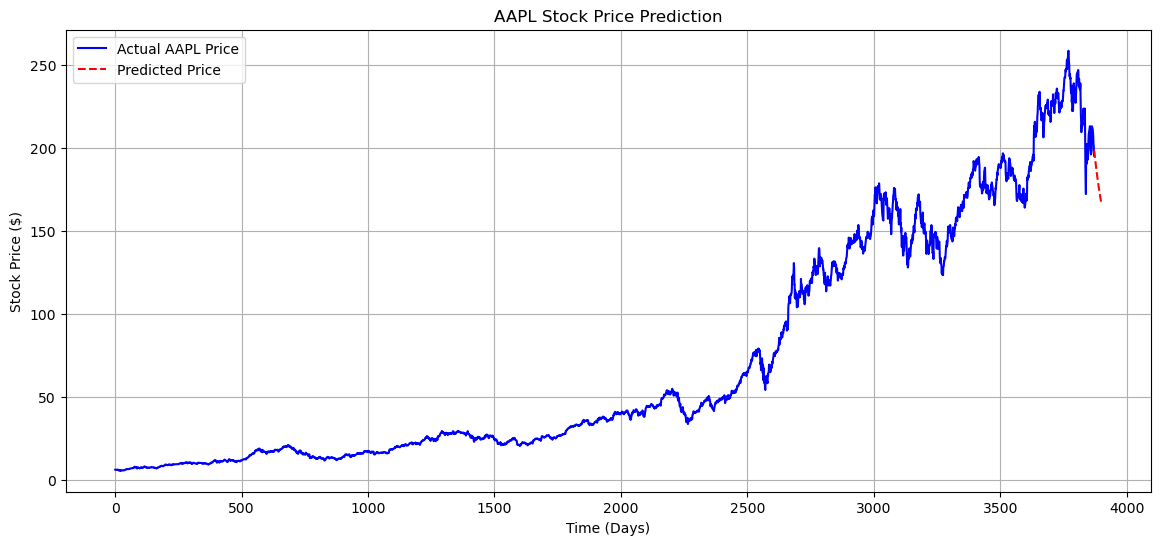


📈 Prediction Summary:
Last Price: $195.27
Predicted Price in 30 days: $165.76
Expected Change: -15.11%


In [47]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Fetch stock data
def get_stock_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data['Close'].values.reshape(-1, 1)  # Use only 'Close' prices

# Preprocess data
def preprocess_data(data, look_back=60):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    X, y = [], []
    for i in range(look_back, len(scaled_data)):
        X.append(scaled_data[i-look_back:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # Reshape for LSTM
    return X, y, scaler

# Build LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25),
        Dense(units=1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train model
def train_model(model, X_train, y_train, epochs=50, batch_size=32):
    early_stopping = EarlyStopping(monitor='loss', patience=5)
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )
    return history

# Predict future prices
def predict_future(model, data, scaler, look_back=60, future_days=30):
    predictions = []
    last_sequence = data[-look_back:]
    last_sequence = scaler.transform(last_sequence)
    
    for _ in range(future_days):
        X_test = np.array([last_sequence[-look_back:, 0]])
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
        
        pred = model.predict(X_test)
        predictions.append(pred[0, 0])
        
        # Update sequence
        new_seq = np.append(last_sequence, pred).reshape(-1, 1)
        last_sequence = new_seq[-look_back:]
    
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return predictions

# Plot results
def plot_results(actual, predicted, ticker):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, color='blue', label=f'Actual {ticker} Price')
    plt.plot(range(len(actual), len(actual) + len(predicted)), 
             predicted, color='red', linestyle='--', label='Predicted Price')
    plt.title(f'{ticker} Stock Price Prediction')
    plt.xlabel('Time (Days)')
    plt.ylabel('Stock Price ($)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main function
def main():
    # User inputs
    ticker = input("Enter stock ticker (e.g., AAPL): ").upper()
    start_date = '2010-01-01'
    end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
    future_days = int(input("How many days to predict? (e.g., 30): "))
    
    # Fetch data
    print(f"\nFetching {ticker} stock data...")
    stock_data = get_stock_data(ticker, start_date, end_date)
    
    if len(stock_data) == 0:
        print("No data found for this ticker. Please try again.")
        return
    
    # Preprocess data
    look_back = 60
    X, y, scaler = preprocess_data(stock_data, look_back)
    
    # Split into train and test sets (80-20)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Build and train LSTM model
    print("\nTraining LSTM model...")
    model = build_lstm_model((X_train.shape[1], 1))
    history = train_model(model, X_train, y_train, epochs=50)
    
    # Predict future prices
    print("\nPredicting future prices...")
    future_prices = predict_future(model, stock_data, scaler, look_back, future_days)
    
    # Plot results
    plot_results(stock_data, future_prices, ticker)
    
    # Print prediction summary
    last_price = stock_data[-1][0]
    predicted_price = future_prices[-1][0]
    change_percent = ((predicted_price - last_price) / last_price) * 100
    
    print("\n📈 Prediction Summary:")
    print(f"Last Price: ${last_price:.2f}")
    print(f"Predicted Price in {future_days} days: ${predicted_price:.2f}")
    print(f"Expected Change: {change_percent:.2f}%")

if __name__ == "__main__":
    print("📊 Stock Price Prediction using LSTM")
    main()

📊 California Housing Dataset:
• Rows: 20640, Columns: 9
• Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
• Target: Median House Value (in $100,000s)


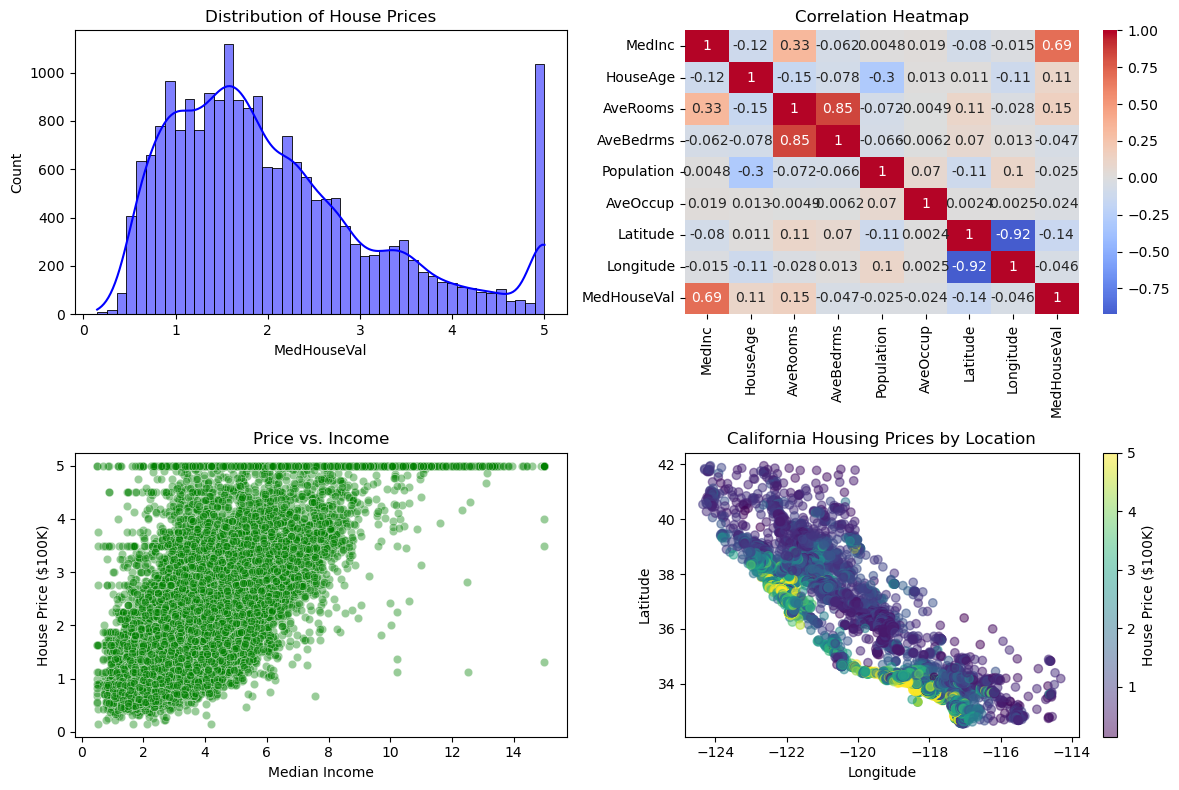

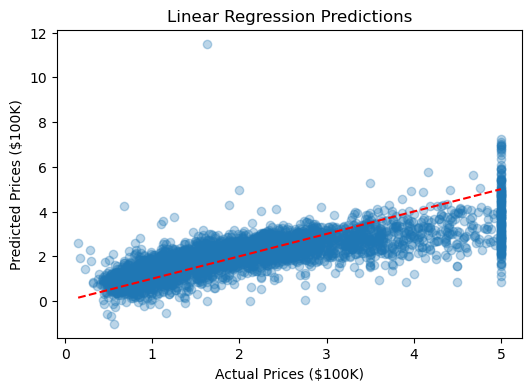


🔍 Linear Regression Performance:
• Mean Squared Error (MSE): 0.5559
• R² Score: 0.5758


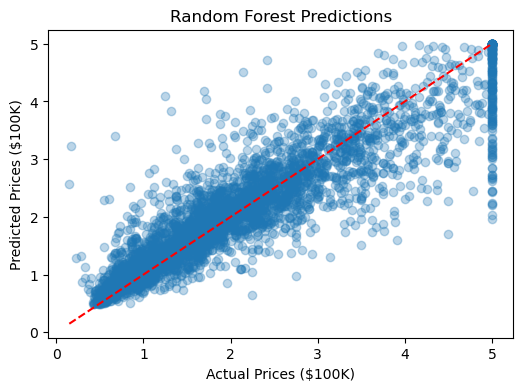


🔍 Random Forest Performance:
• Mean Squared Error (MSE): 0.2552
• R² Score: 0.8053


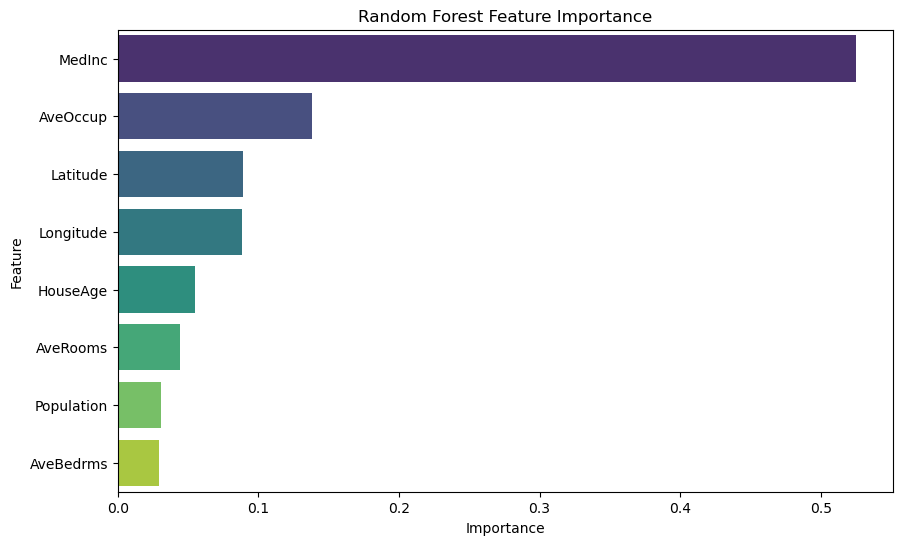


🏠 Sample House Prediction:
• Linear Regression: $-68,985.07
• Random Forest: $118,781.00


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load California housing dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target  # Median house value in $100,000s

# Display dataset info
print("📊 California Housing Dataset:")
print(f"• Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"• Features: {california.feature_names}")
print(f"• Target: Median House Value (in $100,000s)")

# EDA (Exploratory Data Analysis)
def plot_eda(df):
    plt.figure(figsize=(12, 8))
    
    # Distribution of house prices
    plt.subplot(2, 2, 1)
    sns.histplot(df['MedHouseVal'], kde=True, color='blue')
    plt.title("Distribution of House Prices")
    
    # Correlation heatmap
    plt.subplot(2, 2, 2)
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title("Correlation Heatmap")
    
    # Price vs. Median Income
    plt.subplot(2, 2, 3)
    sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.4, color='green')
    plt.xlabel("Median Income")
    plt.ylabel("House Price ($100K)")
    plt.title("Price vs. Income")
    
    # Price vs. Location (Longitude/Latitude)
    plt.subplot(2, 2, 4)
    plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'], cmap='viridis', alpha=0.5)
    plt.colorbar(label="House Price ($100K)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("California Housing Prices by Location")
    
    plt.tight_layout()
    plt.show()

plot_eda(df)

# Preprocess data
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
def train_and_evaluate(models, X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {'MSE': mse, 'R²': r2}
        
        # Plot predictions vs. actual
        plt.figure(figsize=(6, 4))
        plt.scatter(y_test, y_pred, alpha=0.3)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
        plt.xlabel("Actual Prices ($100K)")
        plt.ylabel("Predicted Prices ($100K)")
        plt.title(f"{name} Predictions")
        plt.show()
        
        print(f"\n🔍 {name} Performance:")
        print(f"• Mean Squared Error (MSE): {mse:.4f}")
        print(f"• R² Score: {r2:.4f}")
    
    return results

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate
results = train_and_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test)

# Feature Importance (Random Forest)
rf = models["Random Forest"]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title("Random Forest Feature Importance")
plt.show()

# Predict a sample house
sample_house = np.array([[3.0, 30.0, 5.0, 1.0, 1000.0, 800.0, 35.0, -120.0]])  # Example features
sample_house_scaled = scaler.transform(sample_house)

predicted_price_lr = models["Linear Regression"].predict(sample_house_scaled)[0]
predicted_price_rf = models["Random Forest"].predict(sample_house_scaled)[0]

print("\n🏠 Sample House Prediction:")
print(f"• Linear Regression: ${predicted_price_lr*100000:,.2f}")
print(f"• Random Forest: ${predicted_price_rf*100000:,.2f}")

In [51]:
a=55
b=44
a+b

99

In [53]:
a-b

11

In [55]:
a*b

2420

In [57]:
a**b

37666766318901870271817305235056540626622160294800778501667082309722900390625

In [59]:
a//b

1

In [61]:
a/b

1.25

In [63]:
a%b

11